# Work with Embeddings: Dimensionality Reduction and Clustering for Text Passages

This notebook takes text passages and vector embeddings and uses UMAP to project the vectors to 3D space for visualization. The complete structure (including original metadata and new coordinates) is saved as a JSON file.

## 0. Preliminaries

In [1]:
# Get info about python version
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

/home/awagner/vcs/digicademy/svsal-bertopic/.venv/bin/python
3.11.14 (main, Dec 17 2025, 21:07:37) [Clang 21.1.4 ]
sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


## 1. Setup

### 1.1 Install libraries

Instead of using the below python/ipython commands, and in order to make the notebook more declarative/reproducible, we try to define the necessary libraries and environment in a `uv` *project*, i.e. in the [pyproject.toml file](./pyproject.toml) that controls how `uv` manages the `.venv` virtual environment.

According to the [uv documentation](https://docs.astral.sh/uv/concepts/projects/layout/#the-project-environment):

> To run a command in the project environment, use `uv run`. Alternatively the project environment can be activated as normal for a virtual environment.
>
> When `uv run` is invoked, it will create the project environment if it does not exist yet or ensure it is up-to-date if it exists. The project environment can also be explicitly created with `uv sync`.
>
> It is *not* recommended to modify the project environment manually, e.g., with `uv pip install`. For project dependencies, use `uv add` to add a package to the environment.

### 1.2 Load libraries

In [2]:
import os
import glob
import pickle
from typing import Optional

import polars as pl
import numpy as np
import json
import logging
from umap import UMAP
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### 1.3 Configuration

#### 1.3.1 File paths

In [3]:
# Input directory (produced by 01-embeddings-create notebook)
file_path_in = './out-data'

# The producer notebook creates these output files:
#   - Aggregated:  YYYY-MM-DD_all_docs.{parquet,pkl,csv}  (metadata + embeddings)
#   - Per-provider: {provider_id}_{timestamp}.parquet      (doc_id + embedding)
#   - Manifest:     embeddings_manifest.json               (provider file registry)
#   - Metadata:     YYYY-MM-DD_all_processing_metadata.json
#   - Statistics:   YYYY-MM-DD_all_embedding_statistics.json
#
# The aggregated docs parquet contains metadata columns (url, xmlid, lang, wid,
# author-id, author-name, title, year, passage, citation-recommendation, content)
# plus one embedding column per provider (embeddings_{provider_id}).

#### 1.3.2 Limits

In [4]:
# Here we set the number of documents (paragraphs) to process
# Set it to a lower value until everything runs well, then increase it
# Set it to -1 to process all documents:
max_documents=-1

# Select which provider's embeddings to use for dimensionality reduction.
# Change this index to pick a different provider:
selected_provider_idx = 0

## 2. Utility Functions

### 2.1 Logging Configuration

Configure structured logging for the embedding generation process.

In [5]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

## 3. Read Input Data

### 3.1 Load document and embedding data

In [6]:
def find_latest_file(directory: str, pattern: str) -> Optional[str]:
    """Find the most recent file matching the pattern."""
    files = glob.glob(os.path.join(directory, pattern))
    if not files:
        return None
    files.sort(key=os.path.getmtime, reverse=True)
    return files[0]


def load_docs(directory: str) -> pl.DataFrame:
    """Load document data from the aggregated parquet (includes metadata + embeddings).

    Falls back to loading docs + per-provider parquets via the manifest if no
    aggregated file is available.
    """
    # Primary: aggregated docs parquet (has metadata + embedding columns)
    agg_file = find_latest_file(directory, "*_all_docs.parquet")
    if agg_file:
        logger.info(f"Loading aggregated docs from: {agg_file}")
        return pl.read_parquet(agg_file)

    # Fallback: separate docs + per-provider parquets joined via manifest
    logger.info("No aggregated docs parquet found, falling back to manifest-based loading")

    # Load base docs
    docs_file = find_latest_file(directory, "*_docs.parquet")
    if not docs_file:
        raise FileNotFoundError(f"No docs parquet found in {directory}")
    logger.info(f"Loading docs from: {docs_file}")
    docs = pl.read_parquet(docs_file)

    # Load per-provider embeddings via manifest
    manifest_file = os.path.join(directory, "embeddings_manifest.json")
    if os.path.exists(manifest_file):
        with open(manifest_file) as f:
            manifest = json.load(f)
        for provider_id, info in manifest["providers"].items():
            prov_path = os.path.join(directory, info["file"])
            if os.path.exists(prov_path):
                logger.info(f"Loading embeddings for {provider_id} from: {prov_path}")
                prov_df = pl.read_parquet(prov_path)
                # Cast embedding to Float32 list for consistency
                prov_df = prov_df.with_columns(
                    pl.col("embedding").cast(pl.List(pl.Float32)).alias(f"embeddings_{provider_id}")
                ).drop("embedding")
                docs = docs.join(prov_df, left_on="url", right_on="doc_id", how="left")

    return docs


def load_metadata(directory: str) -> dict:
    """Load processing metadata JSON."""
    metadata_file = find_latest_file(directory, "*_processing_metadata.json")
    if metadata_file:
        logger.info(f"Loading metadata from: {metadata_file}")
        with open(metadata_file) as f:
            return json.load(f)
    return {}


# --- Load all data ---
print("=" * 80)
print("Loading data files...")
print("=" * 80)

docs = load_docs(file_path_in)
metadata = load_metadata(file_path_in)

# Detect available embedding providers
embedding_columns = [c for c in docs.columns if c.startswith("embeddings_")]
embedding_providers = [c.removeprefix("embeddings_") for c in embedding_columns]

print(f"\nLoaded {docs.height} documents")
print(f"Available embedding providers ({len(embedding_providers)}):")
for provider, col in zip(embedding_providers, embedding_columns):
    sample = docs[col].drop_nulls().first()
    dim = len(sample) if sample is not None else "?"
    print(f"  - {provider}  (dim={dim})")

if metadata:
    print(f"\nProcessing metadata:")
    print(f"  Processing date: {metadata.get('processing_date', 'N/A')}")
    if "providers" in metadata:
        print(f"  Providers in metadata: {list(metadata['providers'].keys())}")

2026-02-16 22:29:09,848 - __main__ - INFO - Loading aggregated docs from: ./out-data/2026-01-28_all_docs.parquet


Loading data files...


2026-02-16 22:29:38,476 - __main__ - INFO - Loading metadata from: ./out-data/2026-01-28_all_processing_metadata.json



Loaded 177049 documents
Available embedding providers (3):
  - openai_text-embedding-3-small  (dim=1536)
  - cohere_embed-v4.0_clustering  (dim=1536)
  - google_gemini-embedding-001_SEMANTIC_SIMILARITY  (dim=1536)

Processing metadata:
  Processing date: 2026-01-28 17:53:56
  Providers in metadata: ['openai_text-embedding-3-small', 'cohere_embed-v4.0_clustering', 'google_gemini-embedding-001_SEMANTIC_SIMILARITY']


#### 3.1.1 Data Structure Overview

The loaded data has the following structure:
- **docs**: Polars DataFrame with document metadata (`url`, `content`, `xmlid`, `author-name`, etc.) and one embedding column per provider (`embeddings_{provider_id}`, each a `List(Float32)`).
- **embedding_providers**: List of available provider names (derived from the `embeddings_` column prefix).
- **metadata**: Configuration and processing information from the embedding creation run.

Now, give some information about the data:

In [7]:
print("=" * 80)
print("Data Overview")
print("=" * 80)
print(f"\nShape of docs dataframe: {docs.shape}")
print(f"Number of available documents: {docs.height}")
print(f"\nColumns: {docs.columns}")

print("\nEmbeddings by provider:")
for provider, col in zip(embedding_providers, embedding_columns):
    non_null = docs[col].drop_nulls().len()
    sample = docs[col].drop_nulls().first()
    dim = len(sample) if sample is not None else "?"
    print(f"  {provider}: {non_null} embeddings, dimension={dim}")

print("\nFirst 3 rows of docs dataframe (metadata columns only):")
metadata_cols = [c for c in docs.columns if not c.startswith("embeddings_")]
docs.select(metadata_cols).head(3)

Data Overview

Shape of docs dataframe: (177049, 14)
Number of available documents: 177049

Columns: ['url', 'xmlid', 'lang', 'wid', 'author-id', 'author-name', 'title', 'year', 'passage', 'citation-recommendation', 'content', 'embeddings_openai_text-embedding-3-small', 'embeddings_cohere_embed-v4.0_clustering', 'embeddings_google_gemini-embedding-001_SEMANTIC_SIMILARITY']

Embeddings by provider:
  openai_text-embedding-3-small: 177049 embeddings, dimension=1536
  cohere_embed-v4.0_clustering: 177049 embeddings, dimension=1536
  google_gemini-embedding-001_SEMANTIC_SIMILARITY: 177049 embeddings, dimension=1536

First 3 rows of docs dataframe (metadata columns only):


url,xmlid,lang,wid,author-id,author-name,title,year,passage,citation-recommendation,content
str,str,str,str,str,str,str,i64,str,str,str
"""https://id.salamanca.school/te…","""W0001-01-0006-tp-03e8""","""la""","""W0001""","""A0007""","""Avendaño""","""Thesaurus Indicus""",1668,"""vol. 1""","""Avendaño, Thesaurus Indicus (2…","""R. P. DIDACI DE AVENDA N O SOC…"
"""https://id.salamanca.school/te…","""W0001-01-0008-he-03e8""","""la""","""W0001""","""A0007""","""Avendaño""","""Thesaurus Indicus""",1668,"""vol. 1 praef. 1""","""Avendaño, Thesaurus Indicus (2…","""REGIO INDIARVM CONSILIO inter …"
"""https://id.salamanca.school/te…","""W0001-01-0008-pa-03eb""","""la""","""W0001""","""A0007""","""Avendaño""","""Thesaurus Indicus""",1668,"""vol. 1 praef. 1 paragr. 'THesa…","""Avendaño, Thesaurus Indicus (2…","""THesavrvs Indicvs Regij sane i…"


### 3.2 Select Embedding Provider and Prepare Array

In [8]:
selected_provider = embedding_providers[selected_provider_idx]
selected_column = embedding_columns[selected_provider_idx]
print(f"Selected provider: {selected_provider}")

# Apply max_documents limit
if max_documents > 0:
    docs_subset = docs.head(max_documents)
    print(f"Using first {max_documents} documents (of {docs.height})")
else:
    docs_subset = docs
    print(f"Using all {docs.height} documents")

# Drop rows where the selected embedding is null
docs_subset = docs_subset.filter(pl.col(selected_column).is_not_null())
print(f"Documents with non-null embeddings: {docs_subset.height}")

# Convert the selected embeddings to a numpy array for UMAP
embeddings_array = np.array(docs_subset[selected_column].to_list())
print(f"Embeddings shape: {embeddings_array.shape}")

Selected provider: openai_text-embedding-3-small
Using all 177049 documents
Documents with non-null embeddings: 177049
Embeddings shape: (177049, 1536)


## 4. Run UMAP to Project Vectors to 3D Space

In [9]:
# Configure UMAP
print("Running UMAP dimensionality reduction...")
umap_3d = UMAP(n_components=3,  # Project to 3D
               n_neighbors=15,   # Size of local neighborhood (adjust based on your dataset)
               min_dist=0.1,     # Minimum distance between points in the projection
               metric='cosine',  # Typically used for embeddings
               random_state=42)  # For reproducibility

# Fit and transform the data
embeddings_3d = umap_3d.fit_transform(embeddings_array)

# Add the 3D coordinates to the dataframe
docs_subset = docs_subset.with_columns(
    pl.Series("umap_x", embeddings_3d[:, 0]),
    pl.Series("umap_y", embeddings_3d[:, 1]),
    pl.Series("umap_z", embeddings_3d[:, 2]),
)

print(f"UMAP projection complete. Shape: {embeddings_3d.shape}")

Running UMAP dimensionality reduction...


/home/awagner/vcs/digicademy/svsal-bertopic/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/awagner/vcs/digicademy/svsal-bertopic/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP projection complete. Shape: (177049, 3)


## 5. Visualize the 3D Projection

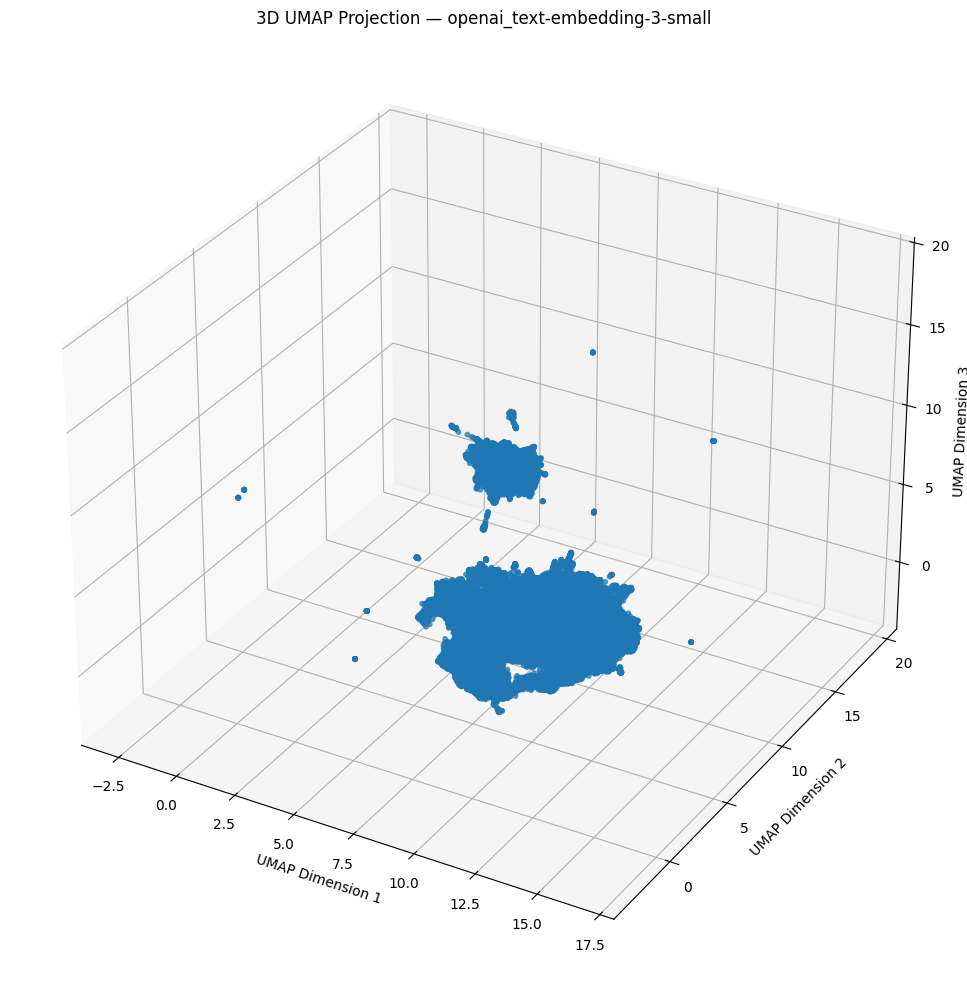

In [10]:
# Create a 3D scatter plot to visualize the projection
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    docs_subset["umap_x"].to_numpy(),
    docs_subset["umap_y"].to_numpy(),
    docs_subset["umap_z"].to_numpy(),
    alpha=0.7,
    s=10,
)

ax.set_title(f"3D UMAP Projection — {selected_provider}")
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
ax.set_zlabel("UMAP Dimension 3")

plt.tight_layout()
plt.show()

## 6. Save the Complete Structure as JSON

In [11]:
# Option to include or exclude embeddings in the output file
include_embeddings = False

# Build the output dataframe: keep UMAP coordinates + selected metadata
drop_cols = [c for c in docs_subset.columns if c.startswith("embeddings_")]
if not include_embeddings:
    print("Excluding embedding columns from output JSON to reduce file size")

# Also drop columns not needed in the output
drop_cols += [c for c in ["content"] if c in docs_subset.columns]
docs_out = docs_subset.drop(drop_cols)

print(f"Output columns: {docs_out.columns}")

Excluding embedding columns from output JSON to reduce file size
Output columns: ['url', 'xmlid', 'lang', 'wid', 'author-id', 'author-name', 'title', 'year', 'passage', 'citation-recommendation', 'umap_x', 'umap_y', 'umap_z']


In [12]:
# Save the output as JSON
print("Converting to JSON...")

output_suffix = "_with_embeddings" if include_embeddings else ""
output_json_file = file_path_in + f"/passages_with_umap_3d_{selected_provider}{output_suffix}.json"

os.makedirs("data", exist_ok=True)

# docs_out.write_json(output_json_file)
docs_out.write_ndjson(output_json_file)

print(f"Saved JSON to {output_json_file}")
file_size_mb = os.path.getsize(output_json_file) / (1024 * 1024)
print(f"File size: {file_size_mb:.2f} MB")

Converting to JSON...
Saved JSON to ./out-data/passages_with_umap_3d_openai_text-embedding-3-small.json
File size: 102.72 MB


## 7. Data Exploration and Analysis of the 3D Projection

In [13]:
# Examine the distribution of points in the UMAP space
print("UMAP 3D Coordinates Statistics:")
print(docs_subset.select("umap_x", "umap_y", "umap_z").describe())

UMAP 3D Coordinates Statistics:
shape: (9, 4)
┌────────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ umap_x    ┆ umap_y    ┆ umap_z    │
│ ---        ┆ ---       ┆ ---       ┆ ---       │
│ str        ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 177049.0  ┆ 177049.0  ┆ 177049.0  │
│ null_count ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ 10.148629 ┆ 4.37473   ┆ 4.619553  │
│ std        ┆ 1.490003  ┆ 1.830655  ┆ 3.363523  │
│ min        ┆ -2.713324 ┆ -3.100331 ┆ -2.792884 │
│ 25%        ┆ 9.179744  ┆ 3.239175  ┆ 2.703075  │
│ 50%        ┆ 9.990988  ┆ 4.392796  ┆ 3.744618  │
│ 75%        ┆ 11.310795 ┆ 5.573716  ┆ 4.824043  │
│ max        ┆ 16.644733 ┆ 19.332968 ┆ 18.737484 │
└────────────┴───────────┴───────────┴───────────┘


In [14]:
# Sample of the JSON output to examine the structure:
# Scan the first 2 records from the output dataframe and convert to JSON for inspection
sample_records = json.loads(docs_out.head(2).write_json())
print("Sample of JSON output (first 2 records):")
print(json.dumps(sample_records, indent=2)[:1000] + "...")

Sample of JSON output (first 2 records):
[
  {
    "url": "https://id.salamanca.school/texts/W0001:vol1.frontmatter.titlepage",
    "xmlid": "W0001-01-0006-tp-03e8",
    "lang": "la",
    "wid": "W0001",
    "author-id": "A0007",
    "author-name": "Avenda\u00f1o",
    "title": "Thesaurus Indicus",
    "year": 1668,
    "passage": "vol. 1",
    "citation-recommendation": "Avenda\u00f1o, Thesaurus Indicus (2019 [1668]), vol. 1, in: The School of Salamanca. A Digital Collection of Sources <https://id.salamanca.school/texts/W0001:vol1.frontmatter.titlepage>",
    "umap_x": 12.091613,
    "umap_y": 4.517248,
    "umap_z": 6.936646
  },
  {
    "url": "https://id.salamanca.school/texts/W0001:vol1.frontmatter.1.heading",
    "xmlid": "W0001-01-0008-he-03e8",
    "lang": "la",
    "wid": "W0001",
    "author-id": "A0007",
    "author-name": "Avenda\u00f1o",
    "title": "Thesaurus Indicus",
    "year": 1668,
    "passage": "vol. 1 praef. 1",
    "citation-recommendation": "Avenda\u00f1o, Thes

## 8. Conclusion

This notebook has successfully:
1. Loaded the CSV file with text passages and embeddings
2. Parsed the vector embeddings from the string format
3. Applied UMAP to project the high-dimensional vectors to 3D space
4. Visualized the 3D projection
5. Saved the complete structure (all original columns plus the 3D coordinates) as a JSON file

The JSON file can now be used for further analysis or visualization in tools like Plotly, D3.js, or other data visualization libraries.